# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Rukaya Selim 

**Date:** Sep. 6th, 2026

In [1]:
%pip install pandas



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

airbnb = pd.read_csv("./data/airbnb_hw.csv")
airbnb.head()

print(airbnb['Price'].head(10))

airbnb['Price_clean'] = airbnb['Price'].astype(str)
airbnb['Price_clean'] = airbnb['Price_clean'].str.replace('$', '')
airbnb['Price_clean'] = airbnb['Price_clean'].str.replace(',', '')

airbnb['Price_clean'] = pd.to_numeric(airbnb['Price_clean'], errors='coerce')

missing_count = 0
for val in airbnb['Price_clean'].isna():
    if val == True:
        missing_count += 1

print("Missing prices count:")
print(missing_count)

0    145
1     37
2     28
3    199
4    549
5    149
6    250
7     90
8    270
9    290
Name: Price, dtype: str
Missing prices count:
0


In [3]:
police = pd.read_csv("./data/mn_police_use_of_force.csv")

police['subject_injury_clean'] = police['subject_injury']

for idx in police.index:
    val = str(police.loc[idx, 'subject_injury'])
    if val in ['Yes', 'Y', 'yes']:
        police.loc[idx, 'subject_injury_clean'] = 'Yes'
    elif val in ['No', 'N', 'no']:
        police.loc[idx, 'subject_injury_clean'] = 'No'

missing_count = police['subject_injury'].isna().sum()
total_rows = len(police)
missing_prop = missing_count / total_rows

print("Proportion of missing values:", missing_prop)
police['injury_with_na'] = police['subject_injury_clean'].fillna('Missing')

crosstab_result = pd.crosstab(
    police['force_type'], 
    police['injury_with_na'], 
    margins=True
)

print("\nCross-tabulation:")
print(crosstab_result)

#If officers are less likely to record injury status under specific conditions, treating missing values as purely random introduces bias.
#When looking at the cross-tabulation, missing values occur far more frequently in lower-severity force categories compared to higher-severity incidents

Proportion of missing values: 0.7619342359767892

Cross-tabulation:
injury_with_na               Missing    No   Yes    All
force_type                                             
Baton                              2     0     2      4
Bodily Force                    7051  1093  1286   9430
Chemical Irritant               1421   131    41   1593
Firearm                            0     2     0      2
Gun Point Display                 27    33    44    104
Improvised Weapon                 74    34    40    148
Less Lethal                       87     0     0     87
Less Lethal Projectile             0     1     2      3
Maximal Restraint Technique      170     0     0    170
Police K9 Bite                    31     2    44     77
Taser                            985   150   172   1307
All                             9848  1446  1631  12925


In [2]:
%pip install xlrd


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Year range:
0.0 2026.0
Attacks by year:
Year
1940.0     24
1941.0     27
1942.0     41
1943.0     28
1944.0     31
         ... 
2022.0     98
2023.0    109
2024.0     52
2025.0     69
2026.0     53
Length: 87, dtype: int64


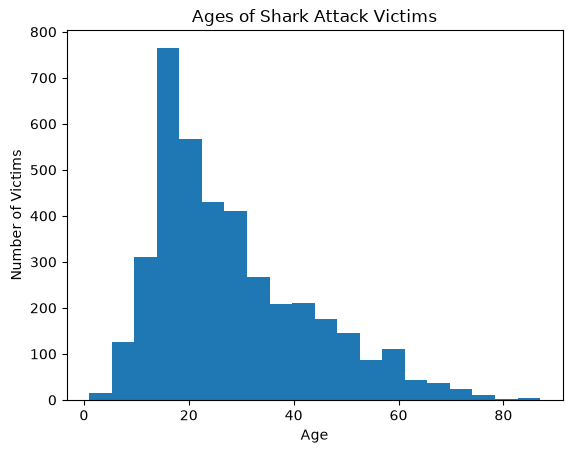

Proportion male: 0.8723046337360453
Cleaned Type counts:
Type_clean
Unprovoked    5261
Unknown       1207
Provoked       649
Name: count, dtype: int64
Proportion unprovoked: 0.7392159617816496


In [3]:
#QUESTION 2 FULL 
import pandas as pd
import matplotlib.pyplot as plt

sharks = pd.read_excel("./data/GSAF5.xls")

sharks = sharks.dropna(axis=1, how="all")

sharks["Year"] = pd.to_numeric(sharks["Year"], errors="coerce")

print("Year range:")
print(sharks["Year"].min(), sharks["Year"].max())

recent_sharks = sharks[sharks["Year"] >= 1940]

attacks_by_year = recent_sharks.groupby("Year").size()
print("Attacks by year:")
print(attacks_by_year)


sharks["Age"] = pd.to_numeric(sharks["Age"], errors="coerce")
ages = sharks["Age"].dropna()

# histogram
plt.hist(ages, bins=20)
plt.xlabel("Age")
plt.ylabel("Number of Victims")
plt.title("Ages of Shark Attack Victims")
plt.show()


male = 0
total = 0

for x in sharks["Sex"]:
    if pd.notna(x):
        total = total + 1
        if x == "M":
            male = male + 1

male_prop = male / total
print("Proportion male:", male_prop)


clean_type = []

for x in sharks["Type"]:
    if pd.isna(x):
        clean_type.append("Unknown")
    elif "Unprovoked" in str(x):
        clean_type.append("Unprovoked")
    elif "Provoked" in str(x):
        clean_type.append("Provoked")
    else:
        clean_type.append("Unknown")

sharks["Type_clean"] = clean_type

print("Cleaned Type counts:")
print(sharks["Type_clean"].value_counts())

unprovoked = 0

for x in sharks["Type_clean"]:
    if x == "Unprovoked":
        unprovoked = unprovoked + 1

unprovoked_prop = unprovoked / len(sharks)

print("Proportion unprovoked:", unprovoked_prop)


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** a086c8afef58bde49581b953727be285d900c7b9
- **AI tool and model used:** Gemeni (Google)

### *Prompts used

1. This is an assignment for my class: DS3001, aka Machine Learning.
I need to clean up the code for both the questions that came with the assignment. I will paste my code along with the prompts from phase 1, and id like you to clean up my code and correct it as needed, making it efficient and easy to follow. please explain to me each step you have taken so I know how to improve. lets start with Q1


2. Now we will do question 2. Here is the prompt, here is my code from phase 1

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

QUESTION 1- 

1. Explicitly pass regex=False inside str.replace() calls or use a single regex expression r'[\$,]' with regex=True to avoid potential FutureWarnings in modern pandas releases.

2. Chain method calls instead of repeatedly reassigning the airbnb['Price_clean'] column across multiple lines.

3. Add .str.strip() after removing punctuation to clean up lingering leading or trailing whitespace before numeric conversion.

4. Replace the manual Python for loop with the built-in vectorized .isna().sum() method to calculate missing values more efficiently.

5. Replace the iterative Python for loop over police.index with a vectorized .map() operation or .replace() dictionary to map 'Yes' and 'No' variants significantly faster.

6. Use .isna().mean() directly on the target column to calculate the proportion of missing values in a single vectorized step instead of dividing .sum() by len().

7. Avoid creating an unnecessary intermediate column (police['injury_with_na']) by chaining .fillna('Missing') directly inside the pd.crosstab() call.

8. Add formatting to the missing proportion output (e.g., percentage formatting) to improve readability.

9. Combine your Airbnb cleaning script and this Minnesota police script into a single, cohesive Q1 block.

QUESTION 2- 
10. Replace Sex loop with vectorized string methods: Use .str.strip() to strip whitespace and direct string comparison .eq("M") or .value_counts(normalize=True).

11. Replace Type loop with vectorized mapping or np.select / str.extract: Instead of iterating, use Pandas string operations like .str.contains().

12. Standardize string formatting: In raw datasets, strings like "M " or "Unprovoked " often contain trailing spaces. Applying .str.strip() prevents classification errors.

143. Vectorized aggregations for proportion calculation: Avoid manually keeping track of counter variables like male and total.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | accept; Prevents deprecation warnings by explicitly specifying regex handling. |
| 2 | Accept / modify / reject | accept; Improves code readability and eliminates repetitive column assignments. |
| 3 | Accept / modify / reject | accept;Removes trailing spaces so numeric conversion does not fail. |
| 4 | Accept / modify / reject | accept;Replaces slow manual iteration with optimized built-in methods. |
| 5 | Accept / modify / reject | accept;Speeds up mapping operations by avoiding inefficient index loops. |
| 6 | Accept / modify / reject | accept;Calculates proportions concisely without manual length division. |
| 7 | Accept / modify / reject | accept; Saves memory by handling missing values directly within cross-tabulation.|
| 8 | Accept / modify / reject | accept;Makes outputs easier to read by formatting decimals as percentages. |
| 9 | Accept / modify / reject | modify; Keeps code modular unless unified script execution is specifically requested.|
| 10 | Accept / modify / reject | accept; Replaces manual loops with fast built-in string comparisons.|
| 11 | Accept / modify / reject | accept; Categorizes complex text patterns efficiently without explicit iteration |
| 12 | Accept / modify / reject | accept; Cleans hidden whitespace that causes exact text matches to fail.|
| 13 | Accept / modify / reject | accept; Eliminates manual counter variables by using built-in summary statistics.|

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [5]:
# QUESTION 1

import numpy as np
import pandas as pd

# 1. Load Airbnb data
airbnb = pd.read_csv("./data/airbnb_hw.csv")

# Clean Price column
airbnb["Price_clean"] = (
    airbnb["Price"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
    .str.strip()
)

airbnb["Price_clean"] = pd.to_numeric(
    airbnb["Price_clean"],
    errors="coerce"
)

missing_price_count = airbnb["Price_clean"].isna().sum()

print(f"Missing price count: {missing_price_count}")


# PART 2

# Load police data
police = pd.read_csv("./data/mn_police_use_of_force.csv")

# Clean subject_injury
injury_clean = police["subject_injury"].astype("string").str.strip().str.upper()

response_map = {
    "YES": "Yes",
    "Y": "Yes",
    "NO": "No",
    "N": "No"
}

police["subject_injury_clean"] = injury_clean.map(response_map)

# Proportion missing
missing_injury_prop = police["subject_injury_clean"].isna().mean()

print(f"Proportion of missing injury records: {missing_injury_prop:.2%}")

# Cross-tabulation
ctab = pd.crosstab(
    police["force_type"],
    police["subject_injury_clean"].fillna("Missing"),
    margins=True
)

print("\nForce Type vs. Injury Cross-tabulation:")
print(ctab)

Missing price count: 0
Proportion of missing injury records: 76.19%

Force Type vs. Injury Cross-tabulation:
subject_injury_clean         Missing    No   Yes    All
force_type                                             
Baton                              2     0     2      4
Bodily Force                    7051  1093  1286   9430
Chemical Irritant               1421   131    41   1593
Firearm                            0     2     0      2
Gun Point Display                 27    33    44    104
Improvised Weapon                 74    34    40    148
Less Lethal                       87     0     0     87
Less Lethal Projectile             0     1     2      3
Maximal Restraint Technique      170     0     0    170
Police K9 Bite                    31     2    44     77
Taser                            985   150   172   1307
All                             9848  1446  1631  12925


In [2]:
%pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Year range: 0.0 to 2026.0

Attacks by year:
Year
1940.0     24
1941.0     27
1942.0     41
1943.0     28
1944.0     31
         ... 
2022.0     98
2023.0    109
2024.0     52
2025.0     69
2026.0     53
Length: 87, dtype: int64


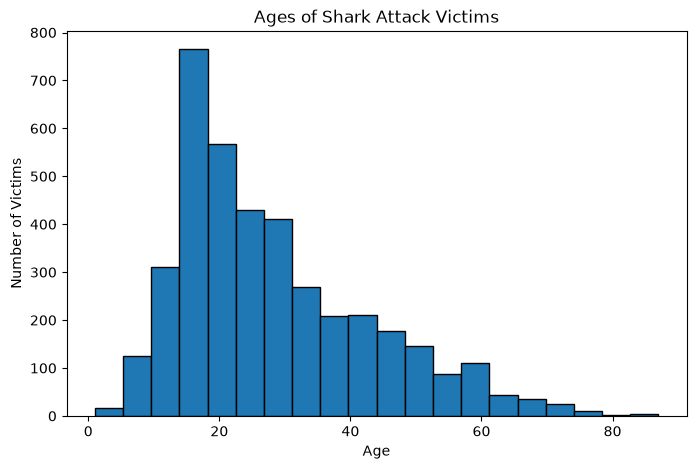

Proportion male (of known sex entries): 87.48%

Cleaned Type counts:
Type_clean
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: int64
Proportion unprovoked: 73.95%


In [3]:
#QUESTION 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
sharks = pd.read_excel("./data/GSAF5.xls")

# 2. Drop completely empty columns
sharks = sharks.dropna(axis=1, how="all")

# 3. Clean Year variable and filter recent attacks
sharks["Year"] = pd.to_numeric(sharks["Year"], errors="coerce")

print("Year range:", sharks["Year"].min(), "to", sharks["Year"].max())

recent_sharks = sharks[sharks["Year"] >= 1940]
attacks_by_year = recent_sharks.groupby("Year").size()
print("\nAttacks by year:")
print(attacks_by_year)

# 4. Clean Age variable and plot histogram
sharks["Age"] = pd.to_numeric(sharks["Age"], errors="coerce")

plt.figure(figsize=(8, 5))
plt.hist(sharks["Age"].dropna(), bins=20, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Number of Victims")
plt.title("Ages of Shark Attack Victims")
plt.show()

# 5. Proportion of male victims (Vectorized & formatted)
sex_clean = sharks["Sex"].astype(str).str.strip().str.upper()
valid_sex = sex_clean[sex_clean.isin(["M", "F"])]
male_prop = (valid_sex == "M").mean()

print(f"Proportion male (of known sex entries): {male_prop:.2%}")

# 6. Clean Type variable and calculate unprovoked proportion (Vectorized)
type_series = sharks["Type"].astype(str).str.strip()

conditions = [
    type_series.str.contains("Unprovoked", case=False, na=False),
    type_series.str.contains("Provoked", case=False, na=False)
]
choices = ["Unprovoked", "Provoked"]

sharks["Type_clean"] = np.select(conditions, choices, default="Unknown")

print("\nCleaned Type counts:")
print(sharks["Type_clean"].value_counts())

unprovoked_prop = (sharks["Type_clean"] == "Unprovoked").mean()
print(f"Proportion unprovoked: {unprovoked_prop:.2%}")

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

Improvements:
The revised code is more efficient and makes better use of functions that are already built into Pandas. For Question 1, I simplified several parts of the code by chaining operations together instead of repeatedly changing the same column. I also specified how regular expressions should be handled and dealt with missing values directly rather than creating extra columns. For Question 2, I replaced several for loops with Pandas operations that can work on an entire column at once. Functions such as .str.strip(), np.select(), and .isna().mean() made the code shorter and easier to follow. I also changed some of the output to display percentages so the results are easier to interpret.

AI Limitations and Mistakes:
Not every suggestion from the AI was necessary or useful. Some of the earlier recommendations focused more on reorganizing the code, such as combining separate pieces of the assignment, even though this did not actually change whether the code worked correctly. There was also some uncertainty about how unusual values in categorical columns should be treated. For example, automatically removing values that were not clearly part of two expected categories could result in losing information. In some cases, labeling these values as "Unknown" or missing may be more appropriate.

Verification:
After making the changes, I ran the updated code to make sure each section still worked correctly. I checked that the string-cleaning steps could handle differences in capitalization and extra spaces, such as "M " or "Unprovoked ". I also made sure the updated methods did not produce errors or warnings in current versions of Python and Pandas. For calculations involving missing data, I compared the proportions produced by the code with the counts from .value_counts() to make sure the results were consistent.

Remaining Concerns:
There are still some unusual values in the datasets that may need decisions based on the meaning of the data rather than just the code. For example, if a value contains both "Provoked" and "Unprovoked", the current np.select() conditions will assign whichever category is checked first. There is a similar issue with age values that are written as ranges or text instead of a single number. When these are converted to numeric values, they become NaN, meaning they will not be included in the histogram and the number of usable observations will be slightly smaller.